In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import quad
import scipy.linalg as la
import funzioni_quant as fq

# Soluzioni numeriche di Schrodinger

In [2]:
#Per risolvere l'equazione di Schrodinger devo partire dall'equazione agli autovalori   H*phi = E*phi, con H l'hamiltoniano, H = K + U = - (h2 / 2m) * (d2/dx2) + U(x)
#Devo tradurre la funzione continua in un array di punti. Divido lo spazio in N punti, da x_min a x_max e scelgo una soglia minima deltax = (x_max - x_min)/N

#L'equazione agli autovalori diventa  M*v = lambda * v, M è la matrice che rappresenta H, v è il vettore phi, lambda è E. 
#Dato che il potenziale è locale nella matrice U(x) compare solo nelle entrate diagonali. V(x)*phi(x_i) = V(x_i)*phi(x_i)
#Mentre l'energia cinetica contiene delle derivate, quindi le traduco computazionalmente con la differenza finita:    f'(x) ≈ [ f(x + Δx) - f(x) ] / Δx
#La derivata seconda diventa:   f''(x_i) ≈ [ f(x_i + Δx) - 2f(x_i) + f(x_i - Δx) ] / (Δx)²
# d²ψ/dx² |_(x=x_i) ≈ [ ψ(x_{i+1}) - 2ψ(x_i) + ψ(x_{i-1}) ] / (Δx)²

#Mi serve una matrice D che moltiplicata a psi mi dia questa differenza finita: deve avere nella riga i-esima: 1 nella colonna i-1, -2 nella colonna i e 1 nella colonna i+1
# T_mat = -(h2 / 2m) * D             H_mat = T_mat + V_mat 


In [3]:
#Per poter calcolare i coefficienti c_n di Schrodinger avrei bisogno di fare degli integrali, ma qua non ho funzioni ma array, pertanto diventano somme
#∫ f*(x)g(x) dx ≈ Σ_i f*[i] * g[i] * Δx

def calculating_cn_sum (phi_initial_array, eigen_matrix, dx):
    #Phi initial array è la distribuzione al tempo 0 
    #Devo ricordarmi di normalizzare sia phi_initial che le eigen_functions
    numero_eigenfunctions = eigen_matrix.shape[1]          #questa mi dice il numero di colonne/autovettori
    c_n = np.zeros(numero_eigenfunctions, dtype=np.complex128)

    for n in range(numero_eigenfunctions):
        phi = eigen_matrix[:, n]                #questa estrae la colonna n-esima
        integrale = np.vdot(phi, phi_initial_array) * dx
        c_n[n] = integrale
    return c_n


def calculating_psi_sum (t, eigen_functions, cn_array, energies_array, h=1):
    fasi = np.exp(-1j * t * (energies_array/h))
    cn_fasi = cn_array * fasi

    #psi_t = eigen_functions @ cn_fasi   #Questo è il prodotto matrice vettore
    psi_t = np.matmul(eigen_functions, cn_fasi)
    return psi_t


def matrice_schrodinger(potential, x, N, h=1, m=1):
    dx = x[1] - x[0]
    
    V = np.diag(potential)

    main_diag = -2 * np.ones(N)
    off_diag = 1 * np.ones(N-1)
    D_mat = (np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)) / dx**2
    H = -(h**2 / (2*m)) * D_mat + V
    return H


def matrice_hamiltoniana(potential_array, x_grid, hbar=1.0, m=1.0):
    """
    Args:
        potential_array (np.ndarray): Un array 1D contenente i valori del potenziale
                                      in ogni punto della griglia x_grid.
        x_grid (np.ndarray): Un array 1D dei punti dello spazio (la griglia).
    Returns:
        np.ndarray: La matrice Hamiltoniana N x N.
    """
    N = len(x_grid)
    if N != len(potential_array):
        raise ValueError("Gli array del potenziale e della griglia devono avere la stessa lunghezza.")
        
    dx = x_grid[1] - x_grid[0]

    main_diag = -2 * np.ones(N)
    off_diag = np.ones(N - 1)
    T_mat = - (hbar**2 / (2 * m)) * \
            (np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)) / dx**2
            
    V_mat = np.diag(potential_array)
    
    H = T_mat + V_mat
    return H



def crank_nicolson(phi_initial, potential, spazio, dt, num_steps):
    H = matrice_hamiltoniana(potential, spazio)
    
    N = len(phi_initial)
    I = np.identity(N, dtype=np.complex128)

    LHS = (I + 1j*(dt/2)*H)
    RHS = (I - 1j*(dt/2)*H)

    phi_current = phi_initial.astype(np.complex128)

    for step in range(num_steps):
        #Devo calcolare il lato destro
        b_vec = np.matmul(RHS, phi_current)

        #Devo risolvere il sistema lineare LHS * psi_next = b_vec
        phi_next = la.solve(LHS, b_vec)

        phi_current = phi_next

    return phi_current


In [4]:
#Parametri unici
m = 1 
h = 1
N = 1000 #numero dei punti
L = 10 #dimensione
mu = L/2
sigma = 0.5
k0 = 5
t0 = 2
A = 1.0 / (2 * np.pi * sigma**2)**0.25



x = np.linspace(0, L, N)
dx = x[1] - x[0]

V0 = 1e9 
potential = np.zeros_like(x)
potential[x < 0] = V0
potential[x > L] = V0
"""
#Scelgo un potenziale arbitrario: V(x)=0.5 * k * x**2
k = 1.01
#potential = 0.5 * k * (x - L/2)**2   #lo faccio centrato in L/2
#potential = 1/(x + k)**2

V_mat = np.diag(potential)

#Matrice del potenziale
main_diag = -2 * np.ones(N)
off_diag = 1 * np.ones(N-1)
D_mat = (np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)) / dx**2

#Matrice totale
H = -(h**2 / (2*m)) * D_mat + V_mat"""

#potential = 0*x
H = matrice_hamiltoniana(potential, x)

#Soluzione del problema agli autovalori 
# 'energie' è un array con gli autovalori (le energie)
# 'functioni_onda' è una matrice dove ogni colonna è un autovettore (una funzione d'onda). Le COLONNE sono autofunzioni/autovettori
energie, funzioni_onda = la.eigh(H)
eigen_func_normalized = funzioni_onda / np.sqrt(dx)

In [5]:
#Per poter calcolare i cn ho bisogno di una distribuzione al tempo 0
phi_initial_sium = A * np.exp((-(x - mu)**2)/(4 * (sigma)**2)) * np.exp(1j * k0 * x / h)
#Devo essere sicuro di aver normalizzato phi
norma_iniziale = np.sqrt(np.sum(np.abs(phi_initial_sium)**2) * dx)
phi_initial = phi_initial_sium / norma_iniziale 


#Calcolo dei c_n
cn = calculating_cn_sum (phi_initial, eigen_func_normalized, dx)


#Calcolo la psi ad un tempo specifico 
t0 = 2
psi_totale = calculating_psi_sum(t0, eigen_func_normalized, cn, energie)


#Verifiche che Somma(|c_n|^2) = 1, e che int(|Psi(x, t)|^2) = 1
somma_cn = sum(np.abs(c)**2 for c in cn)
print(f"\nSomma totale dei coefficienti (|c_n|^2): {somma_cn:.3f}")

somma_psi = sum(np.abs(psi)**2 for psi in psi_totale) * (dx)
print(f"\nSomma totale delle probabilità (|Psi(x, t=t0)|^2): {somma_psi:.3f}")


Somma totale dei coefficienti (|c_n|^2): 1.000

Somma totale delle probabilità (|Psi(x, t=t0)|^2): 1.000


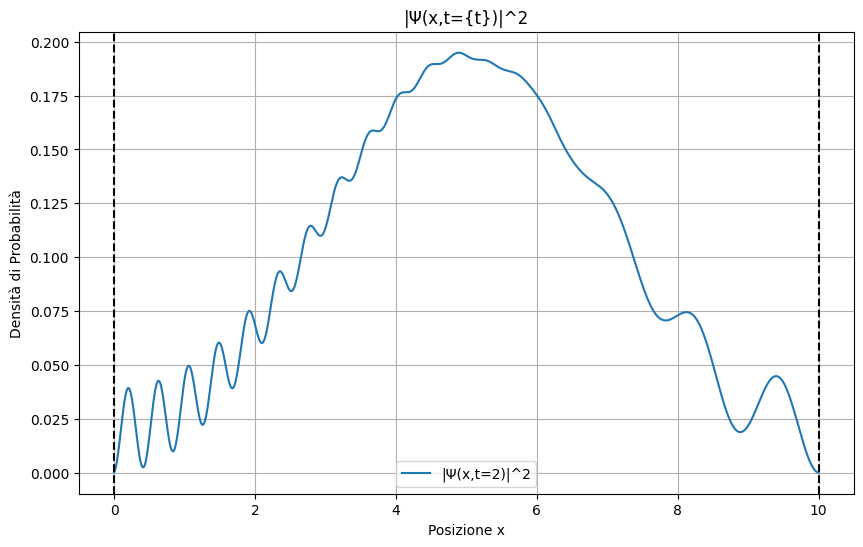

In [6]:
#Plotting del modulo quadro, cioè densità di probabilità
densita_probabilita = np.abs(psi_totale)**2
x_vals = np.linspace(-2, L + 2, 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, densita_probabilita, label=f'|Ψ(x,t={t0})|^2')
plt.axvline(0, color='k', linestyle='--') # Muro sinistro
plt.axvline(L, color='k', linestyle='--') # Muro destro
plt.xlabel("Posizione x")
plt.ylabel("Densità di Probabilità")
plt.title('|Ψ(x,t={t})|^2')
plt.grid(True)
plt.legend()
plt.show()

# Confronto con la soluzione analitica


Somma totale dei coefficienti (|c_n|^2): 1.000
Verifica normalizzazione a t=2: Integrale |Psi(x,t)|^2 dx = 1.000


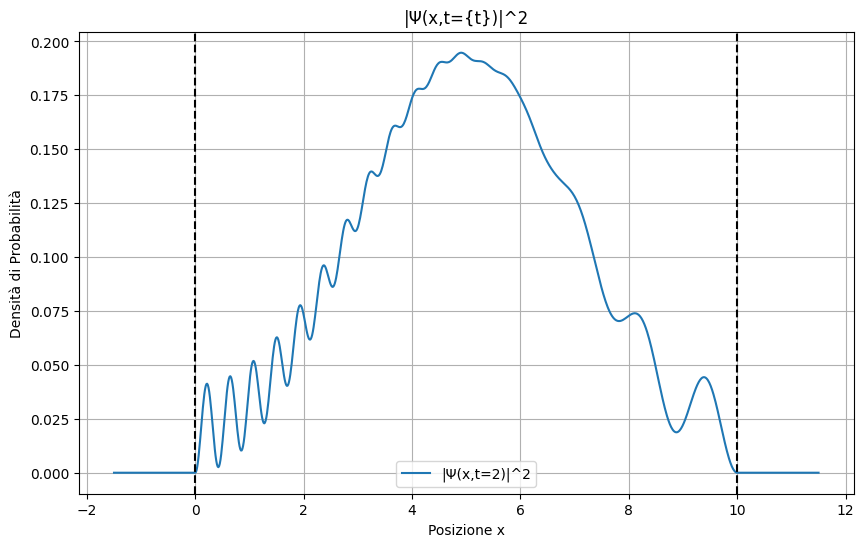

In [7]:
def f(x, A, mu, sigma, k0):           #a t=0 funzione d'onda gaussiana
    fase = np.exp(1j * k0 * x)
    gaussiana = A*np.exp(-((x-mu)**2)/(4*(sigma**2)))
    tot = gaussiana * fase
    return tot

def phi(x, n, L):
    b = np.sqrt(2 / L)
    c = np.sin((n * np.pi * (x / L)))
    val_inside = b * c
    return np.where((x >= 0) & (x <= L), val_inside, 0.0)

def energia(n, L):
    E = ((n*np.pi)**2)/(2*(L**2))
    return E

#Per poter integrare devo passare una funzione, non un array
#Creo quindi una funzione che calcola |Psi(x,t)|^2
def prob_density(x, t, c_n, energy_func, basis_func, params_dict):
    valore_psi = fq.psi(x, t, c_n, energy_func, basis_func, **params_dict)
    return np.abs(valore_psi)**2


N = 50
params_for_f = {'A': A, 'mu': mu, 'sigma': sigma, 'k0': k0}
params_for_phi = {'L': L}
c_n = fq.calculating_cn (N, f, phi, 0, L, params_for_f, params_for_phi)
somma_c = sum(np.abs(c)**2 for c in c_n)
print(f"\nSomma totale dei coefficienti (|c_n|^2): {somma_c:.3f}")


x_vals = np.linspace(-1.5, L + 1.5, 1000)
t = 2 
psi_vals = np.zeros_like(x_vals, dtype=complex)

for i, xp in enumerate(x_vals):
    psi_vals[i] = fq.psi(xp, t, c_n, energia, phi, L=L)
modulo_psi = np.abs(psi_vals)**2
parametri = {'L': L}
argomenti = (t, c_n, energia, phi, parametri)

integrale_modulo, _ = quad(prob_density, 0, L, args = argomenti)
print(f"Verifica normalizzazione a t={t}: Integrale |Psi(x,t)|^2 dx = {integrale_modulo:.3f}")

#Plotting del modulo quadro, cioè densità di probabilità
plt.figure(figsize=(10, 6))
plt.plot(x_vals, modulo_psi, label=f'|Ψ(x,t={t})|^2')
plt.axvline(0, color='k', linestyle='--') # Muro sinistro
plt.axvline(L, color='k', linestyle='--') # Muro destro
plt.xlabel("Posizione x")
plt.ylabel("Densità di Probabilità")
plt.title('|Ψ(x,t={t})|^2')
plt.grid(True)
plt.legend()
plt.show()

*Plotting del confronto tra numerico ed analitico*

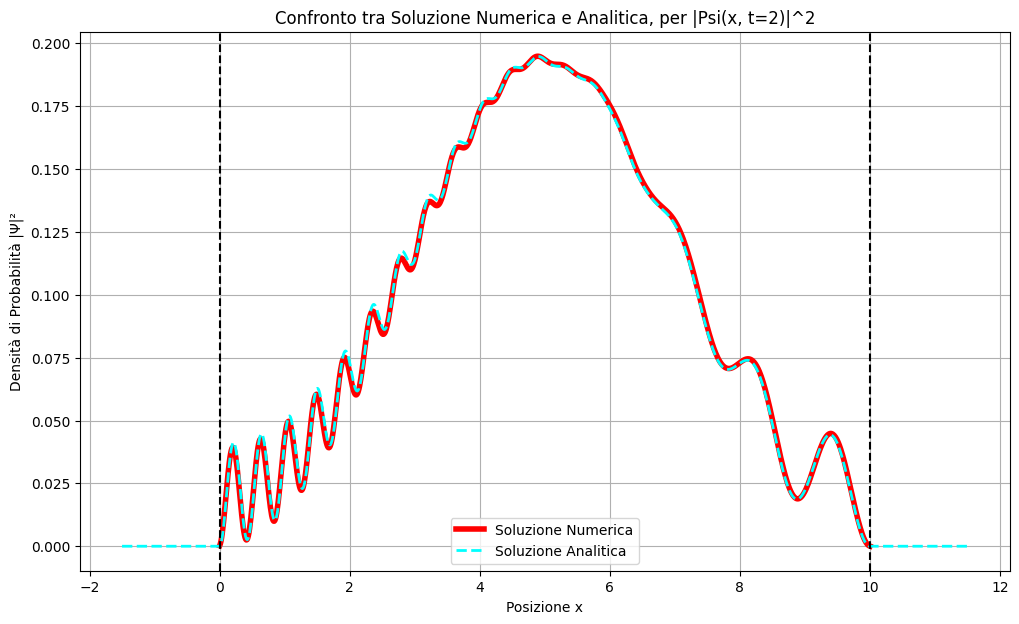

In [8]:
plt.figure(figsize=(12, 7))
plt.plot(x, densita_probabilita, label='Soluzione Numerica', color='red', linewidth=4)
plt.plot(x_vals, modulo_psi, label='Soluzione Analitica', color='cyan', linestyle='--', linewidth=2)
plt.axvline(0, color='k', linestyle='--') # Muro sinistro
plt.axvline(L, color='k', linestyle='--') # Muro destro
plt.xlabel("Posizione x")
plt.ylabel("Densità di Probabilità |Ψ|²")
plt.title("Confronto tra Soluzione Numerica e Analitica, per |Psi(x, t=2)|^2")
plt.legend()
plt.grid(True)
plt.show()

# Altro Metodo (Migliore)

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.sparse import identity

In [10]:
#Parto sempre da Psi(x, 0), discretizzo lo spazio come ho fatto prima, poi devo fare dei passi deltat e calcolo Psi(x, deltat) per tutti i t in un ciclo.
#Devo usare la formula (I - i(Δt/2ħ)H) Ψ(t+Δt) = (I + i(Δt/2ħ)H) Ψ(t), dove I è l'identità e H la matrice di prima. Per ogni t devo risolvere un'equazione del tipo A*x = b

#(Ψ(t + Δt) - Ψ(t)) / Δt = - (i / ħ) * H * [ (Ψ(t) + Ψ(t + Δt)) / 2 ]                       e diventa (I + i(Δt/2ħ)H) * Ψ(t + Δt) = (I - i(Δt/2ħ)H) * Ψ(t)
#Ho quindi due matrici a destra e a sinita                 sx LHS = (I + i(Δt/2ħ)H)      dx RHS = (I - i(Δt/2ħ)H)

In [11]:
m = 1 
h = 1
N2 = 1500 #numero dei punti
L = 10 #dimensione
mu = L/2
sigma = 0.5
k0 = 5
t0 = 2

x2 = np.linspace(-2, L + 2, N2)
dx2 = x2[1] - x2[0]

A = 1.0 / (2 * np.pi * sigma**2)**0.25
phi_initial_unnorm = A * np.exp((-(x2 - mu)**2)/(4 * (sigma)**2)) * np.exp(1j * k0 * x2 / h)
norm_factor = np.sqrt(np.sum(np.abs(phi_initial_unnorm)**2) * dx2)
phi_initial = phi_initial_unnorm / norm_factor



#potential = 1/(1 + x**2)
V0 = 1e9 
potential = np.zeros_like(x2)
potential[x2 < 0] = V0
potential[x2 > L] = V0
#potential = 0*x2
H2 = matrice_hamiltoniana(potential, x2)

dt = 0.001
tempo = 2
n_steps2 = int(tempo/dt)

In [12]:
psi_finale = crank_nicolson(phi_initial, potential, x2, dt, n_steps2)

Norma finale con Crank-Nicolson: 1.0000


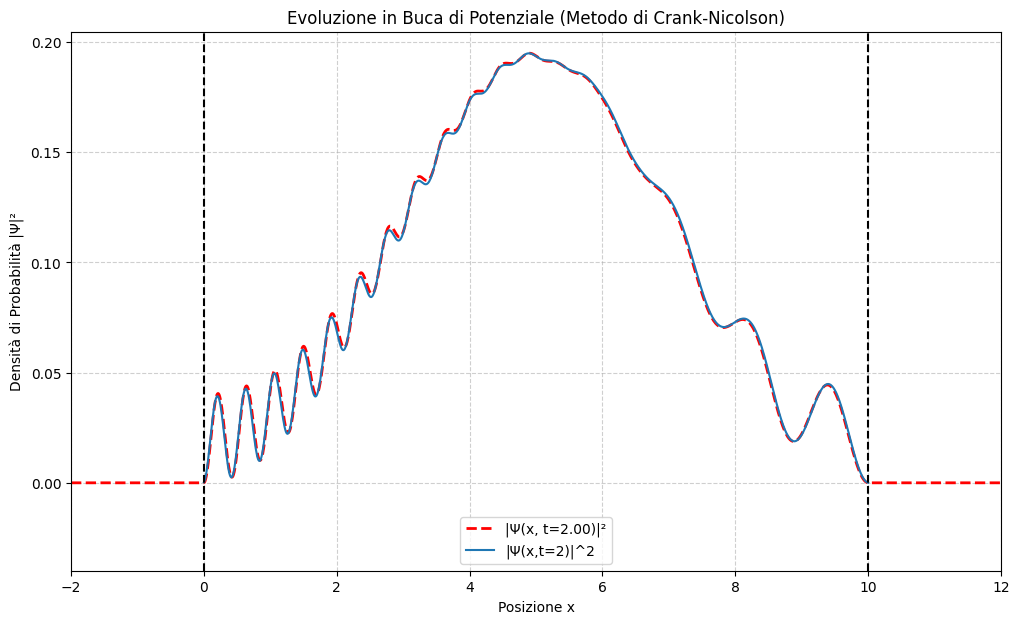

In [13]:
norma_finale_cn = np.sum(np.abs(psi_finale)**2) * dx2
print(f"Norma finale con Crank-Nicolson: {norma_finale_cn:.4f}")


plt.figure(figsize=(12, 7))
x_val = np.linspace(-2, L + 2, N)
prob_density_initial = np.abs(phi_initial)**2
prob_density_final = np.abs(psi_finale)**2

#Plot del potenziale 
#plt.plot(x, prob_density_initial, color='blue', linewidth=2, label=f'|Ψ(x, t=0)|²')
plt.plot(x2, prob_density_final, color='red', linestyle='--', linewidth=2, label=f'|Ψ(x, t={tempo:.2f})|²')
densita_probabilita = np.abs(psi_totale)**2
x_vals = np.linspace(-2, L + 2, 1000)
plt.plot(x, densita_probabilita, label=f'|Ψ(x,t={t0})|^2')

# Aggiungiamo il plot del potenziale per vedere i muri
#scaled_potential = (potential / V0) * np.max(prob_density_initial) # Scaliamo per visibilità
#plt.plot(x2, scaled_potential, color='black', linestyle=':', label='Potenziale V(x) (riscalato)')

plt.title("Evoluzione in Buca di Potenziale (Metodo di Crank-Nicolson)")
plt.xlabel("Posizione x")
plt.ylabel("Densità di Probabilità |Ψ|²")

# Le linee verticali ora mostrano i muri del potenziale che hai creato
plt.axvline(0, color='k', linestyle='--') 
plt.axvline(L, color='k', linestyle='--') 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(bottom=-0.05 * np.max(prob_density_initial)) # Un po' di spazio sotto
plt.xlim(x2[0], x2[-1]) 
plt.show()